In [6]:
import os 
import sys
sys.path.append('/home/hbvision/mirsaid/smart-office')
from ultralytics import YOLO
import cv2

data_images = '/home/hbvision/mirsaid/smart-office/data/hb-uzb'
model = YOLO('/home/hbvision/mirsaid/smart-office/models/yolov8m-face.pt')

for filename in os.listdir(data_images):
    image = cv2.imread(os.path.join(data_images, filename))

    # Detect and crop face
    yolo_results = model(image, max_det=1, verbose=False)

    x1, y1, x2, y2, _, _ = yolo_results[0].boxes.data[0].cpu().numpy()

    face_image = image[int(y1):int(y2), int(x1):int(x2)]

    # save image to the folder
    cv2.imwrite(f'/home/hbvision/mirsaid/smart-office/data/hb-uzb/{filename}-cropped.jpg', face_image)

In [16]:
import os
import cv2
import dlib
import numpy as np
from tqdm import tqdm

# Define the FaceAligner class using your align_face method
class FaceAligner:
    def __init__(self):
        self.dlib_detector = dlib.get_frontal_face_detector()
        self.dlib_predictor = dlib.shape_predictor(
            "/home/hbvision/mirsaid/smart-office/models/shape_predictor_68_face_landmarks.dat")  # Ensure this path is correct

    def align_face(self, face, size=160):
        # Convert to grayscale for Dlib
        gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
        # Detect faces
        rects = self.dlib_detector(gray, 1)
        print(rects)

        if len(rects) == 0:
            return None # No face detected, return None instead of original image
        
        # Get landmarks for the first detected face
        shape = self.dlib_predictor(gray, rects[0])
        if shape is None:
            return None
        
        landmarks = np.array([[shape.part(i).x, shape.part(i).y] for i in range(68)])
        
        # Extract eye coordinates
        left_eye = landmarks[36:42].mean(axis=0).astype(int)
        right_eye = landmarks[42:48].mean(axis=0).astype(int)
        
        # Calculate angle
        dY = right_eye[1] - left_eye[1]
        dX = right_eye[0] - left_eye[0]
        angle = np.degrees(np.arctan2(dY, dX)) * -1 # Negative for correct rotation
        
        # Center of the image
        center = (face.shape[1] // 2, face.shape[0] // 2)
        
        # Compute rotation matrix
        M = cv2.getRotationMatrix2D(center, angle, scale=1.0)
        
        # Align the image
        aligned = cv2.warpAffine(face, M, (face.shape[1], face.shape[0]))

        return aligned
    
# === PROCESSING SCRIPT ===

# Set this to the path of your image database
database_path = "/home/hbvision/mirsaid/smart-office/data/hb-uzb"
save_path = os.path.join(database_path, "aligned")
os.makedirs(save_path, exist_ok=True)

# Initialize the face aligner
aligner = FaceAligner()

# Valid image extensions
valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}

# Process each image file
for root, dirs, files in os.walk(database_path):
    for file in tqdm(files, desc="Aligning faces"):
        if os.path.splitext(file)[1].lower() in valid_extensions:
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            aligned = aligner.align_face(img)

            if aligned is not None:
                # Preserve subdirectory structure
                relative_path = os.path.relpath(root, database_path)
                target_dir = os.path.join(save_path, relative_path)
                os.makedirs(target_dir, exist_ok=True)

                output_path = os.path.join(target_dir, file)
                cv2.imwrite(output_path, aligned)

Aligning faces:  29%|██▊       | 2/7 [00:00<00:00, 11.26it/s]

rectangles[[(-31, 43) (216, 266)]]
rectangles[[(-107, 159) (780, 958)]]


Aligning faces:  57%|█████▋    | 4/7 [00:00<00:00, 11.03it/s]

rectangles[[(-107, 159) (780, 958)]]
rectangles[[(15, 57) (201, 242)]]


Aligning faces:  86%|████████▌ | 6/7 [00:00<00:00,  9.82it/s]

...

rectangles[[(-107, 159) (780, 958)]]
rectangles[[(-27, 57) (180, 242)]]


Aligning faces:  86%|████████▌ | 6/7 [00:00<00:00,  9.98it/s]

rectangles[[(-128, 192) (936, 1150)]]
rectangles[[(-44, 27) (312, 348)]]


Aligning faces: 100%|██████████| 7/7 [00:00<00:00,  8.58it/s]

rectangles[[(-128, 298) (936, 1256)]]


In [3]:
import cv2
import pandas as pd
import random

video_names = ['videoa1-5']

for video_name in video_names:
    gt_path = f'/home/hbvision/mirsaid/smart-office/TrackEval/data/gt/mot_challenge/ilhan-train/{video_name}/gt/gt.txt'
    video_path = f'/home/hbvision/mirsaid/smart-office/client/pred_videos/{video_name}_eval.mp4'

    # Load ground truth data
    gt_data = pd.read_csv(gt_path, header=None)
    gt_data.columns = ['frame', 'id', 'x', 'y', 'w', 'h', 'conf', 'class', 'visibility']

    # Sort by frame number and filter visible objects
    gt_data = gt_data.sort_values(by='frame')

    # Assign a random color to each object ID
    id_colors = {}
    unique_ids = gt_data['id'].unique()
    for obj_id in unique_ids:
        id_colors[obj_id] = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))


    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out = cv2.VideoWriter(f'output_{video_name}.avi', cv2.VideoWriter_fourcc(*'XVID'), 30, (width, height))

    frame_num = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_num += 1
        frame_data = gt_data[gt_data['frame'] == frame_num]

        for _, row in frame_data.iterrows():
            if row['class'] != 1:
                continue

            x, y, w, h = int(row['x']), int(row['y']), int(row['w']), int(row['h'])
            obj_id = int(row['id'])
            visibility = row['visibility']

            # Get color for the current object ID
            color = id_colors[obj_id]

            # Draw bounding box
            cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)

            # Add text for ID and visibility level
            text = f'ID: {obj_id}, Vis: {visibility:.2f}'
            cv2.putText(frame, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        out.write(frame)
        cv2.imshow('Tracking', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Cleanup
    out.release()
    cap.release()
    cv2.destroyAllWindows()
    print(f'Video {video_name} processed', end='')

Video videoa1-5 processed

In [5]:
import numpy as np
import pandas as pd

gt_path = f'/home/hbvision/mirsaid/smart-office/TrackEval/data/gt/mot_challenge/hbface-train/video10/gt/gt.txt'
pred_path = f'/home/hbvision/mirsaid/smart-office/results/video10_recognition_alg1.txt'

# Get unique track IDs from ground truth
gt_df = pd.read_csv(gt_path, names=['frame', 'track_id', 'x', 'y', 'w', 'h', 'confidence', 'class', 'visibility'])
gt_df = gt_df[['frame', 'track_id']]
gt_df = gt_df.drop_duplicates(subset=['track_id'])

gt_ids = set(gt_df['track_id'])
gt_ids_aranged = np.arange(1, len(gt_ids) + 1)

# Get unique track IDs from predictions
pred_df = pd.read_csv(pred_path, names=['frame', 'x', 'y', 'w', 'h', 'name'])
unique_names = pred_df['name'].unique()
pred_ids_aranged = np.arange(1, len(unique_names) + 1)

# Calculate accuracy with aranged IDs
correct = len(set(gt_ids_aranged) & set(pred_ids_aranged))
total = len(gt_ids_aranged)

accuracy = correct / total if total > 0 else 0

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7500


In [11]:
import face_alignment
from skimage import io
import cv2
import numpy as np

# Initialize face alignment
#fa = # Blazeface (front camera model)
fa = face_alignment.FaceAlignment(landmarks_type= face_alignment.LandmarksType.TWO_D, face_detector='blazeface')

def align_face(image_path, bbox):
    """ Align face using keypoints from a YOLO bbox """
    # x, y, w, h = bbox  # YOLOv8 bbox format: [x, y, w, h]
    # img = io.imread(image_path)
    cropped_face = cv2.imread(image_path)

    # Detect facial landmarks
    landmarks = fa.get_landmarks(cropped_face)
    
    if landmarks is None:
        return cropped_face  # No landmarks detected, return original crop

    # Get eye coordinates for alignment
    left_eye = landmarks[0][36:42].mean(axis=0)  # Left eye mean
    right_eye = landmarks[0][42:48].mean(axis=0)  # Right eye mean

    # Align face using affine transformation
    desired_left_eye = (0.35, 0.4)
    desired_right_eye = (0.65, 0.4)

    desired_w, desired_h = 112, 112  # Aligned face size
    eyes_center = ((left_eye + right_eye) / 2).astype(int)

    # Compute affine transform matrix
    affine_matrix = cv2.getAffineTransform(
        src=np.float32([left_eye, right_eye, eyes_center]),
        dst=np.float32([
            (desired_left_eye[0] * desired_w, desired_left_eye[1] * desired_h),
            (desired_right_eye[0] * desired_w, desired_right_eye[1] * desired_h),
            (desired_w / 2, desired_h / 2),
        ])
    )

    aligned_face = cv2.warpAffine(cropped_face, affine_matrix, (desired_w, desired_h))
    return aligned_face

# Example Usage
bbox = [100, 50, 150, 150]  # Example YOLO face bbox
aligned_face = align_face("//home/hbvision/mirsaid/smart-office/data/hb-kor/Mirsaid_5.jpg", bbox)

# save image to the folder
cv2.imwrite(f'/home/hbvision/mirsaid/smart-office/face_aligned.jpg', aligned_face)


True

In [9]:
Image.fromarray(faces[0]).save('/home/hbvision/mirsaid/smart-office/face.jpg')

In [ ]:
import cv2
import numpy as np
import torch
import sys
import os
sys.path.append('/home/hbvision/mirsaid/smart-office')
from ultralytics import YOLO
import face_alignment

# Initialize the face alignment model
fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, device='cuda' if torch.cuda.is_available() else 'cpu')

# Load YOLOv8 face detection model
model = YOLO('/home/hbvision/mirsaid/smart-office/models/yolov8m-face.pt')

def align_face(image, bbox):
    # Expand the bbox slightly to ensure all landmarks are visible
    x1, y1, x2, y2 = bbox
    h, w = image.shape[:2]
    
    # Ensure box is within image boundaries
    x1, y1 = max(0, int(x1)), max(0, int(y1))
    x2, y2 = min(w, int(x2)), min(h, int(y2))
    
    # Crop the face using the bounding box
    face_crop = image[y1:y2, x1:x2]
    
    try:
        # Get facial landmarks (returns a list of detected faces)
        landmarks = fa.get_landmarks(face_crop)
        
        if landmarks is None or len(landmarks) == 0:
            return face_crop  # Return unaligned if no landmarks detected
            
        landmarks = landmarks[0]  # Get first detected face landmarks
        
        # Calculate eyes position (based on landmarks)
        left_eye = landmarks[36:42].mean(axis=0)
        right_eye = landmarks[42:48].mean(axis=0)
        
        # Calculate angle for alignment
        dx = right_eye[0] - left_eye[0]
        dy = right_eye[1] - left_eye[1]
        angle = np.degrees(np.arctan2(dy, dx))
        
        # Calculate center of the image
        center = (face_crop.shape[1] // 2, face_crop.shape[0] // 2)
        
        # Get rotation matrix
        M = cv2.getRotationMatrix2D(center, angle, 1)
        
        # Apply affine transformation
        aligned_face = cv2.warpAffine(face_crop, M, (face_crop.shape[1], face_crop.shape[0]))
        
        return aligned_face
    except Exception as e:
        print(f"Error in face alignment: {e}")
        return face_crop  # Return original crop if alignment fails

def process_video(video_path, output_path=None):
    cap = cv2.VideoCapture(video_path)
    
    # Initialize video writer if output path is provided
    writer = None
    if output_path:
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
    
    track_history = {}  # Store aligned faces for each track ID
    
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break
        
        # Run YOLOv8 tracking on the frame
        results = model.track(frame, persist=True)
        
        # Verify if tracking was successful and boxes were detected
        if results[0].boxes is not None and hasattr(results[0].boxes, 'id'):
            if results[0].boxes.id is None:
                continue
            boxes = results[0].boxes.xyxy.cpu().numpy()
            track_ids = results[0].boxes.id.cpu().numpy()
            
            # Process each detection with its track ID
            for box, track_id in zip(boxes, track_ids):
                x1, y1, x2, y2 = box
                
                # Align the face
                aligned_face = align_face(frame, box)
                
                # Store the aligned face for this track ID
                track_history[int(track_id)] = aligned_face
                
                # Draw box on the frame
                cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
                cv2.putText(frame, f"ID: {int(track_id)}", (int(x1), int(y1) - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                
                # Optional: Display aligned face on the frame
                if aligned_face is not None:
                    h, w = aligned_face.shape[:2]
                    # Resize for display if too large
                    display_size = 100
                    ratio = display_size / max(h, w)
                    display_face = cv2.resize(aligned_face, (int(w * ratio), int(h * ratio)))
                    
                    # Place the aligned face in the corner corresponding to the track ID
                    x_pos = (int(track_id) % 5) * display_size
                    y_pos = (int(track_id) // 5) * display_size
                    
                    try:
                        frame[y_pos:y_pos+display_face.shape[0], x_pos:x_pos+display_face.shape[1]] = display_face
                    except:
                        pass  # Skip if the face doesn't fit
        
        # Display the frame
        cv2.imshow("YOLOv8 Face Tracking with Alignment", frame)
        
        # Write the frame if needed
        if writer:
            writer.write(frame)
        
        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Release resources
    cap.release()
    if writer:
        writer.release()
    cv2.destroyAllWindows()
    
    return track_history  # Return the history of aligned faces by track ID

# Example usage
if __name__ == "__main__":
    # Process a video file
    aligned_faces_by_id = process_video("/home/hbvision/mirsaid/smart-office/client/pred_videos/videoa1-1_eval.mp4", "output_video.mp4")
    
    # You can now access all aligned faces for each tracked ID
    for track_id, aligned_face in aligned_faces_by_id.items():
        # Save the last aligned face for each ID
        cv2.imwrite(f"aligned_face_id_{track_id}.jpg", aligned_face)


0: 544x960 4 faces, 8.0ms
Speed: 1.5ms preprocess, 8.0ms inference, 0.5ms postprocess per image at shape (1, 3, 544, 960)
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small

0: 544x960 4 faces, 7.8ms
Speed: 1.8ms preprocess, 7.8ms inference, 1.0ms postprocess per image at shape (1, 3, 544, 960)
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small
Error in face alignment: Given input size: (512x2x1). Calculated outpu

/home/hbvision/mirsaid/smart-office/myenv/lib/python3.10/site-packages/face_alignment/api.py:147: UserWarning: No faces were detected.
  warnings.warn("No faces were detected.")


Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small

0: 544x960 5 faces, 7.7ms
Speed: 1.5ms preprocess, 7.7ms inference, 0.5ms postprocess per image at shape (1, 3, 544, 960)
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small
Error in face alignment: Given input size: (512x2x1). Calculated output size: (512x1x0). Output size is too small
Error in face alignment: Given input size: (512x2x1). Calculated output size: (

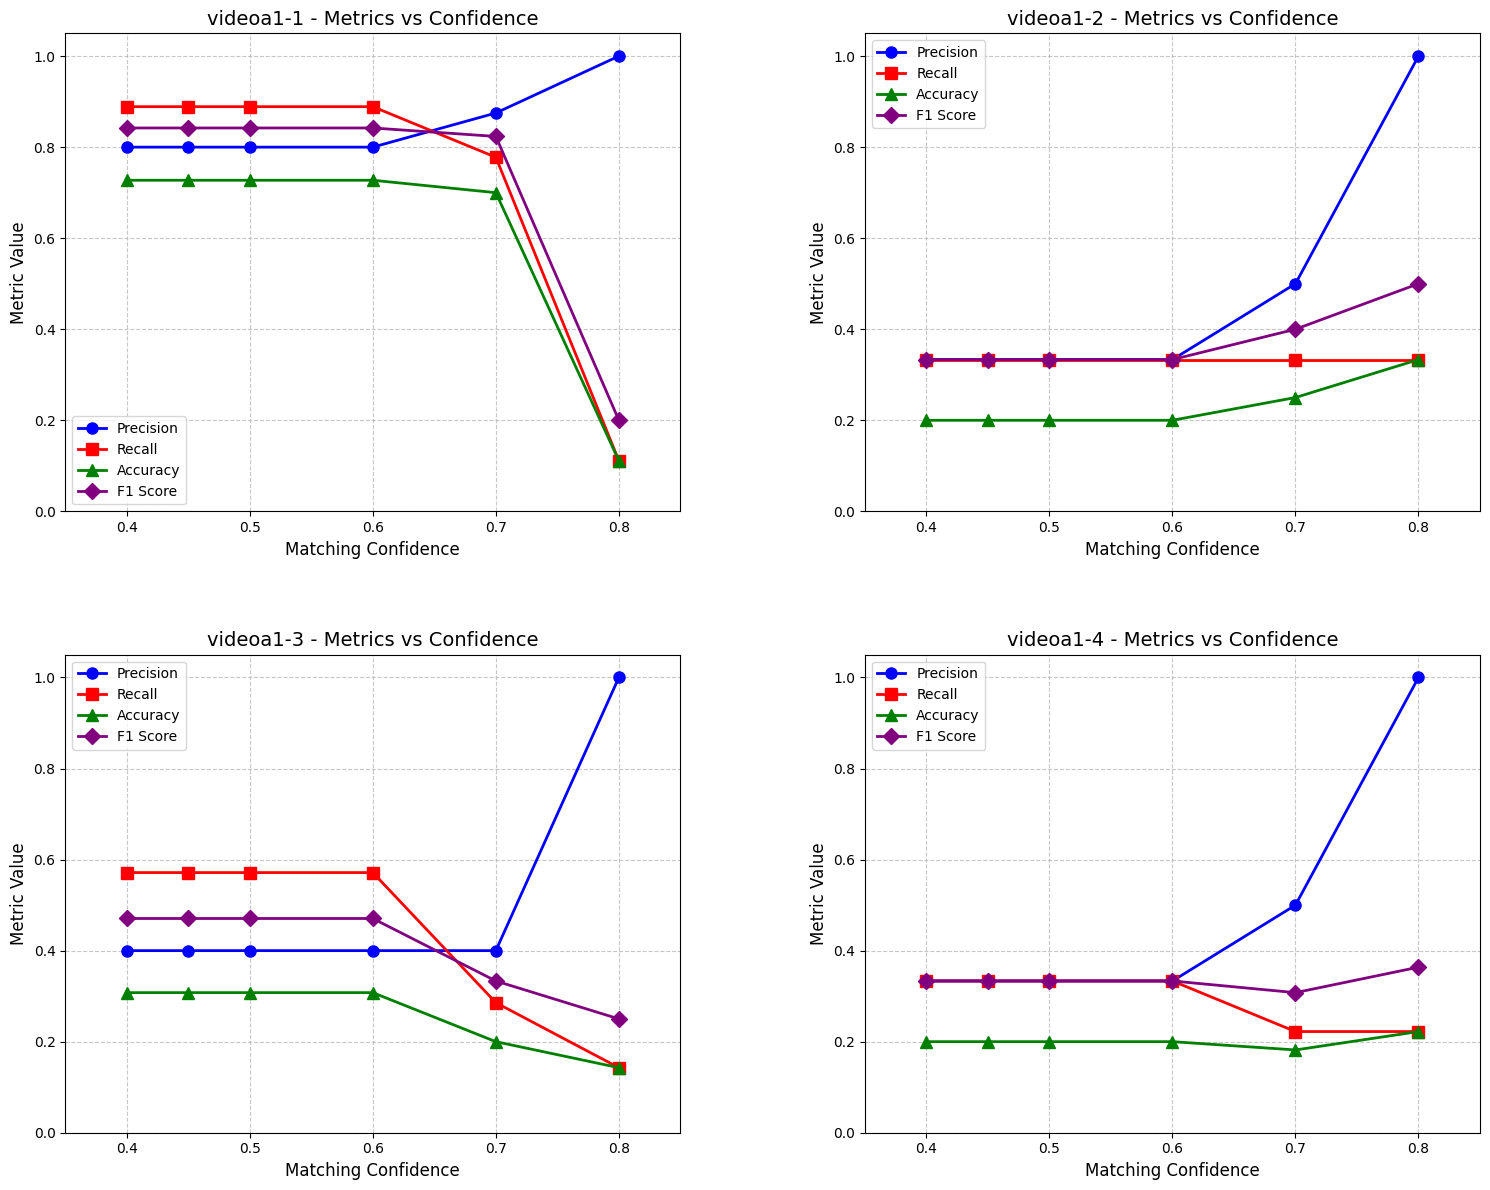

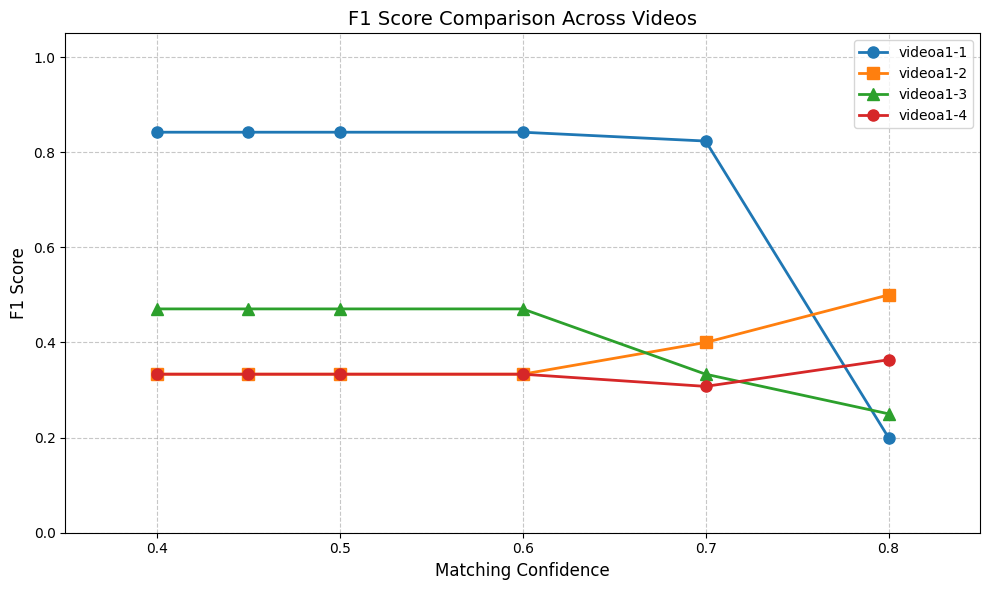

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Data from the input
df = pd.read_csv('data.csv')

# Get unique videos and confidence thresholds
videos = df['Video Name'].unique()
confidences = sorted(df['Matching Confidence'].unique())

# Metrics to plot
metrics = ['Precision', 'Recall', 'Accuracy']

# Create a 2x2 grid of subplots (one for each video)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()  # Flatten to make indexing easier

# Define colors and markers for different metrics
colors = ['blue', 'red', 'green']
markers = ['o', 's', '^']

# For each video, create a plot with all metrics
for i, video in enumerate(videos):
    ax = axes[i]
    
    # Filter data for this video
    video_data = df[df['Video Name'] == video]
    
    # Sort by confidence
    video_data = video_data.sort_values('Matching Confidence')
    
    # Calculate F1 score
    precision = video_data['Precision']
    recall = video_data['Recall']
    f1 = 2 * (precision * recall) / (precision + recall)
    
    # Plot each metric
    for j, metric in enumerate(metrics):
        ax.plot(video_data['Matching Confidence'], video_data[metric], 
                marker=markers[j], color=colors[j], label=metric, linewidth=2, markersize=8)
    
    # Plot F1 score
    ax.plot(video_data['Matching Confidence'], f1, 
            marker='D', color='purple', label='F1 Score', linewidth=2, markersize=8)
    
    ax.set_xlabel('Matching Confidence', fontsize=12)
    ax.set_ylabel('Metric Value', fontsize=12)
    ax.set_title(f'{video} - Metrics vs Confidence', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlim(0.35, 0.85)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Add a title for the entire figure
#fig.suptitle('Metrics vs Matching Confidence for Each Video', fontsize=16, y=0.98)

# Save figure
plt.savefig('metrics_by_video.png', dpi=300, bbox_inches='tight')

# Show plot
plt.show()

# Optional: Create a single plot showing F1 scores for all videos for comparison
plt.figure(figsize=(10, 6))
for i, video in enumerate(videos):
    # Filter data for this video
    video_data = df[df['Video Name'] == video]
    
    # Sort by confidence
    video_data = video_data.sort_values('Matching Confidence')
    
    # Calculate F1 score
    precision = video_data['Precision']
    recall = video_data['Recall']
    f1 = 2 * (precision * recall) / (precision + recall)
    
    # Plot F1 score
    plt.plot(video_data['Matching Confidence'], f1, 
             marker=markers[i % len(markers)], label=video, linewidth=2, markersize=8)

plt.xlabel('Matching Confidence', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Score Comparison Across Videos', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0.35, 0.85)
plt.ylim(0, 1.05)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=300)
plt.show()

In [4]:
import sys
sys.path.append('/home/hbvision/mirsaid/smart-office')
import ultralytics
import cv2
import numpy as np
import torch

video_path = '/home/hbvision/mirsaid/smart-office/in.mp4'
cap = cv2.VideoCapture(video_path)
model = ultralytics.YOLO('/home/hbvision/mirsaid/smart-office/models/yolov8m-face.pt')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Perform inference
    results = model.track(frame, persist=True)

    annotated_frame = results[0].plot()

    # Display the results
    cv2.imshow('YOLO Detection', annotated_frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



0: 544x960 1 face, 9.2ms
Speed: 1.6ms preprocess, 9.2ms inference, 0.5ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 face, 9.5ms
Speed: 1.3ms preprocess, 9.5ms inference, 0.6ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 face, 11.1ms
Speed: 1.9ms preprocess, 11.1ms inference, 0.8ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 face, 9.9ms
Speed: 2.6ms preprocess, 9.9ms inference, 0.7ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 face, 9.0ms
Speed: 1.3ms preprocess, 9.0ms inference, 1.1ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 face, 8.6ms
Speed: 1.6ms preprocess, 8.6ms inference, 0.5ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 face, 8.9ms
Speed: 1.3ms preprocess, 8.9ms inference, 0.5ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 face, 9.7ms
Speed: 1.3ms preprocess, 9.7ms inference, 0.5ms postprocess per image at shape (1, 3, 544, 960)

0: 544x960 1 face, 9.

KeyboardInterrupt: 